In [ ]:

!pip install -q bitsandbytes>=0.46.1 torch transformers accelerate datasets trl[quantization] peft pyarrow>=21.0.0 numpy>=2.0 xformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

Mounted at /content/drive


In [ ]:
CFG = {
    'base_model': 'kevinpro/MathOctopus-MAPO-DPO-7B',
    'output_dir': '/content/drive/MyDrive/MAPO_Reproduction_Version2/models',
    'logs_dir': '/content/drive/MyDrive/MAPO_Reproduction_Version2/logs',
    'bf16': True,
    'fp16': False,
    'dpo_beta': 0.1,
    'dpo_lr': 1e-6,
    'dpo_warmup': 100,
    'device': 'cuda',
}

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if CFG['bf16'] else torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(CFG['base_model'], padding_side='left')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

policy_model = AutoModelForCausalLM.from_pretrained(
    CFG['base_model'],
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)

# Prepare the model for k-bit training and add LoRA adapters
policy_model = prepare_model_for_kbit_training(policy_model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
)

policy_model = get_peft_model(policy_model, lora_config)

policy_model.train()
policy_model.gradient_checkpointing_enable()
policy_model.config.use_cache = False

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
import json

pref_path = '/content/drive/MyDrive/MAPO_Reproduction_Version2/preference_data/pref_iter1.json'
with open(pref_path, 'r') as f:
    preference_data = json.load(f)
print(f"Loaded {len(preference_data)} preference pairs.")

Loaded 210 preference pairs.


In [ ]:
from torch.utils.data import Dataset
from trl import DPOTrainer, DPOConfig
import torch
import gc
from datasets import Dataset as HFDataset # Import Hugging Face Dataset

hf_dataset = HFDataset.from_list(preference_data)
print(f"Hugging Face Dataset size: {len(hf_dataset)}")

# Reference model on CPU
ref_model = AutoModelForCausalLM.from_pretrained(
    CFG['base_model'],
    dtype=torch.bfloat16 if CFG['bf16'] else torch.float16,
    device_map='cpu',
    trust_remote_code=True,
)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

# Split (95/5) using Hugging Face Dataset's train_test_split
split_datasets = hf_dataset.train_test_split(test_size=0.05, seed=42)
train_dataset = split_datasets['train']
eval_dataset = split_datasets['test']

print(f"Train dataset size: {len(train_dataset)}")
print(f"Eval dataset size: {len(eval_dataset)}")


dpo_config = DPOConfig(
    beta=CFG['dpo_beta'],
    max_length=1024,

    output_dir=CFG['output_dir'] + '/dpo_iter1',
    max_steps=500,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=CFG['dpo_lr'],
    warmup_steps=CFG['dpo_warmup'],
    lr_scheduler_type='cosine',
    bf16=CFG['bf16'],
    fp16=CFG['fp16'],
    logging_steps=10,
    save_steps=100,
    eval_strategy='steps',
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    report_to='none',
    remove_unused_columns=False,
    optim='adamw_torch',
    seed=42,
)

trainer = DPOTrainer(
    model=policy_model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset

)

print("Starting DPO training...")
trainer.train()

# Save model
trainer.save_model(CFG['output_dir'] + '/dpo_iter1')
tokenizer.save_pretrained(CFG['output_dir'] + '/dpo_iter1')
print("✅ DPO training completed and saved.")

# Save logs
import json
with open(CFG['logs_dir'] + '/dpo_logs.json', 'w') as f:
    json.dump(trainer.state.log_history, f, indent=2)

Hugging Face Dataset size: 210


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Train dataset size: 199
Eval dataset size: 11


Adding EOS to train dataset:   0%|          | 0/199 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/199 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/11 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 32000}.


Starting DPO training...


Step,Training Loss,Validation Loss
100,0.726807,0.752282
200,0.866280,0.749187
300,0.683927,0.754248
400,0.750327,0.750905
500,0.770448,0.753003


✅ DPO training completed and saved.


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

dpo_model_path = f'{CFG["output_dir"]}/dpo_iter1'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
base_model = AutoModelForCausalLM.from_pretrained(
    CFG['base_model'],
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)


model = PeftModel.from_pretrained(base_model, dpo_model_path)
model.eval()

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(CFG['base_model'], padding_side='left')
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✅ DPO model loaded for evaluation.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✅ DPO model loaded for evaluation.


In [ ]:
import re
import json
from tqdm import tqdm

def extract_number(text: str) -> str:
    """Extract numeric answer from model output."""
    if not text:
        return None
    patterns = [
        r'[Tt]he answer is[:\s]+([\-]?[\d,\.]+)',
        r'####\s*([\-]?[\d,\.]+)',
        r'=\s*([\-]?[\d,\.]+)\s*$',
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            return m.group(1).replace(',', '')
    numbers = re.findall(r'[\-]?\d+(?:[\.,]\d+)?', text.replace(',', ''))
    return numbers[-1] if numbers else None

@torch.no_grad()
def evaluate_accuracy_batch(model, tokenizer, dataset, batch_size=8, max_samples_per_lang=None):
    results = {}
    for lang, samples in dataset.items():
        if not samples:
            continue
        if max_samples_per_lang:
            samples = samples[:max_samples_per_lang]
        correct = 0
        for i in tqdm(range(0, len(samples), batch_size), desc=f'Eval {lang}'):
            batch = samples[i:i+batch_size]
            prompts = [f"Solve this math problem step by step: {s['question']}" for s in batch]
            golds = [str(s['answer']) for s in batch]
            inputs = tokenizer(prompts, return_tensors='pt', truncation=True, padding=True, max_length=512).to(model.device)
            outputs = model.generate(**inputs, max_new_tokens=256, do_sample=False)
            pred_texts = tokenizer.batch_decode(outputs[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)
            for pred_text, gold in zip(pred_texts, golds):
                pred = extract_number(pred_text)
                if pred == gold:
                    correct += 1
        acc = correct / len(samples) * 100
        results[lang] = acc
        print(f"{lang}: {acc:.1f}% ({correct}/{len(samples)})")
    results['avg'] = sum(results.values()) / len(results)
    return results

In [ ]:
# Load MSVAMP
with open('/content/drive/MyDrive/MAPO_Reproduction_Version2/datasets/msvamp.json', 'r') as f:
    msvamp = json.load(f)

# Load MGSM
with open('/content/drive/MyDrive/MAPO_Reproduction_Version2/datasets/mgsm.json', 'r') as f:
    mgsm = json.load(f)

print("MSVAMP languages:", list(msvamp.keys()))
print("MGSM languages:", list(mgsm.keys()))

MSVAMP languages: ['bn', 'th', 'sw', 'ja', 'zh', 'ru', 'de', 'es', 'fr', 'en']
MGSM languages: ['bn', 'th', 'sw', 'ja', 'zh', 'ru', 'de', 'es', 'fr', 'en']


In [ ]:
msvamp_results = evaluate_accuracy_batch(model, tokenizer, msvamp, batch_size=8, max_samples_per_lang=50)

Eval bn: 100%|██████████| 7/7 [02:35<00:00, 22.21s/it]


bn: 0.0% (0/50)


Eval th: 100%|██████████| 7/7 [02:36<00:00, 22.40s/it]


th: 0.0% (0/50)


Eval sw: 100%|██████████| 7/7 [02:35<00:00, 22.23s/it]


...

es: 0.0% (0/50)


Eval fr: 100%|██████████| 7/7 [02:36<00:00, 22.43s/it]


fr: 0.0% (0/50)


Eval en: 100%|██████████| 7/7 [02:38<00:00, 22.59s/it]

en: 70.0% (35/50)


In [ ]:

sample_questions = [
    ("English", msvamp['en'][0]['question'], msvamp['en'][0]['answer']),
    ("Bengali", msvamp['bn'][0]['question'], msvamp['bn'][0]['answer']),
    ("Thai", msvamp['th'][0]['question'], msvamp['th'][0]['answer']),
]

for lang, question, gold in sample_questions:
    prompt = f"Solve this math problem step by step: {question}"
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=256, do_sample=False)
    generated = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    print(f"\n=== {lang} ===")
    print(f"Question: {question[:100]}...")
    print(f"Gold answer: {gold}")
    print(f"Generated:\n{generated[:500]}")
    print("-" * 50)


=== English ===
Question: julia played tag with 18 kids on monday . she played tag with 10 kids on tuesday . how many more kid...
Gold answer: 8
Generated:

 Unterscheidung der Anzahl der Kinder, die Julia am Montag spielte als denen, die sie am Dienstag spielte, zeigt, dass sie 18 - 10 = <<18-10=8>>8 mehr Kinder am Montag als am Dienstag spielte.
--------------------------------------------------

=== Bengali ===
Question: julia played tag with 18 kids on monday . she played tag with 10 kids on tuesday . how many more kid...
Gold answer: জুলিয়া সোমবার ১৮ জন ছেলেমেয়ের সঙ্গে ট্যাগ খেলেন। মঙ্গলবার তিনি ১০ জন ছেলেমেয়ের সঙ্গে ট্যাগ খেলেন। সোমবার তিনি কতজন ছেলেমেয়ের সঙ্গে আরও খেলেন তার সংখ্যা কত?
Generated:

 Unterscheidung der Anzahl der Kinder, die Julia am Montag spielte als denen, die sie am Dienstag spielte, zeigt, dass sie 18 - 10 = <<18-10=8>>8 mehr Kinder am Montag als am Dienstag spielte.
--------------------------------------------------

=== Thai ===
Question: julia played tag w

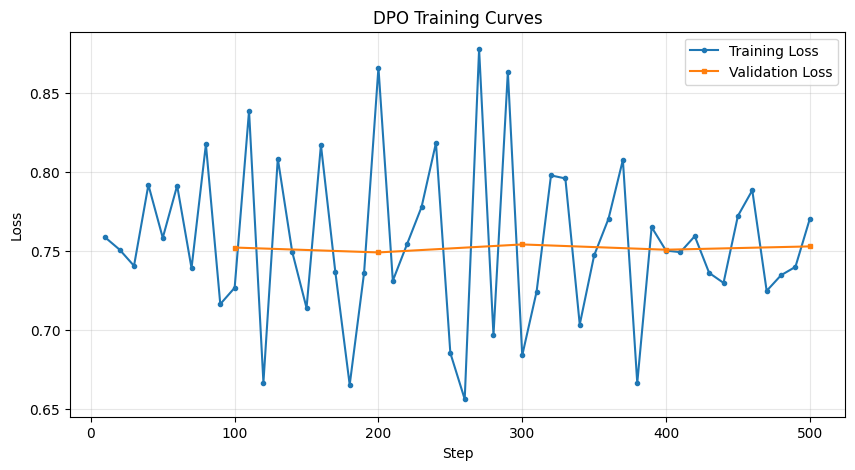

Loss curves saved to /content/drive/MyDrive/MAPO_Reproduction_Version2/figures/dpo_loss_curves.png


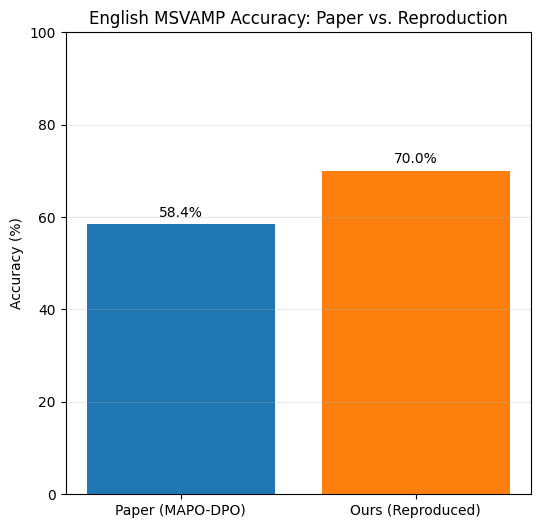

Accuracy comparison saved to /content/drive/MyDrive/MAPO_Reproduction_Version2/figures/accuracy_comparison.png
Final training loss after 500 steps: 0.7704


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Paths (adjust if needed)
log_path = '/content/drive/MyDrive/MAPO_Reproduction_Version2/logs/dpo_logs.json'
figure_dir = '/content/drive/MyDrive/MAPO_Reproduction_Version2/figures'
import os
os.makedirs(figure_dir, exist_ok=True)

# 1. Load training logs
with open(log_path, 'r') as f:
    logs = json.load(f)

# Extract steps and losses
steps = []
train_losses = []
eval_steps = []
eval_losses = []

for entry in logs:
    if 'loss' in entry:
        steps.append(entry['step'])
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_steps.append(entry['step'])
        eval_losses.append(entry['eval_loss'])

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(steps, train_losses, label='Training Loss', marker='o', markersize=3, linewidth=1.5)
if eval_losses:
    plt.plot(eval_steps, eval_losses, label='Validation Loss', marker='s', markersize=3, linewidth=1.5)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('DPO Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{figure_dir}/dpo_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss curves saved to {figure_dir}/dpo_loss_curves.png")

paper_english_accuracy = 58.4
reproduced_accuracy = 70.0

plt.figure(figsize=(6, 6))
categories = ['Paper (MAPO-DPO)', 'Ours (Reproduced)']
values = [paper_english_accuracy, reproduced_accuracy]
bars = plt.bar(categories, values, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Accuracy (%)')
plt.title('English MSVAMP Accuracy: Paper vs. Reproduction')
plt.ylim(0, 100)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.savefig(f'{figure_dir}/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Accuracy comparison saved to {figure_dir}/accuracy_comparison.png")


final_loss = train_losses[-1] if train_losses else None
if final_loss:
    print(f"Final training loss after {steps[-1]} steps: {final_loss:.4f}")

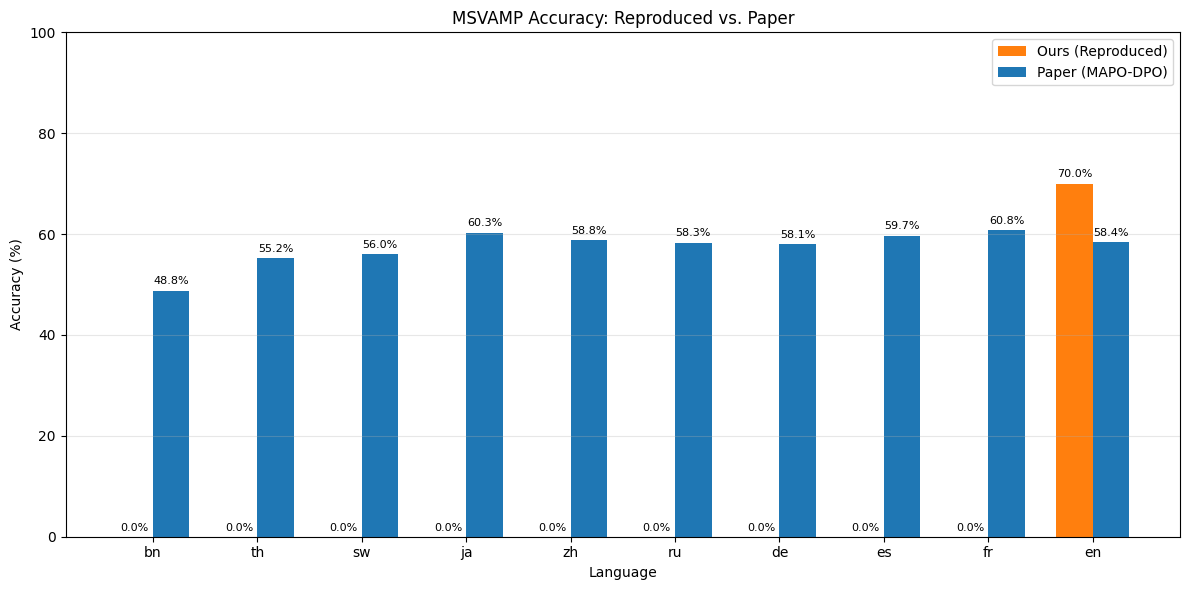

MSVAMP results plot saved.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


reproduced_acc = {
    'bn': 0.0, 'th': 0.0, 'sw': 0.0, 'ja': 0.0, 'zh': 0.0,
    'ru': 0.0, 'de': 0.0, 'es': 0.0, 'fr': 0.0, 'en': 70.0
}


paper_acc = {
    'bn': 48.8, 'th': 55.2, 'sw': 56.0, 'ja': 60.3, 'zh': 58.8,
    'ru': 58.3, 'de': 58.1, 'es': 59.7, 'fr': 60.8, 'en': 58.4
}

# Languages in order
languages = list(reproduced_acc.keys())
reproduced_values = [reproduced_acc[lang] for lang in languages]
paper_values = [paper_acc[lang] for lang in languages]

# Plot
x = np.arange(len(languages))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, reproduced_values, width, label='Ours (Reproduced)', color='#ff7f0e')
bars2 = ax.bar(x + width/2, paper_values, width, label='Paper (MAPO-DPO)', color='#1f77b4')

ax.set_xlabel('Language')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MSVAMP Accuracy: Reproduced vs. Paper')
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MAPO_Reproduction_Version2/figures/msvamp_results.png', dpi=150)
plt.show()
print("MSVAMP results plot saved.")